In [1]:
import pandas as pd
df = pd.read_csv("GO.csv")
df.rename(columns={df.columns[0]: "Gene"}, inplace=True)
print(df.shape)
df.head()

(1124, 8642)


,Gene,GO:0006793,GO:0006796,GO:0008150,GO:0008152,GO:0009987,GO:0044237,GO:0016310,GO:0006464,GO:0006807,...,GO:0036510,GO:0036511,GO:0036512,GO:0007060,GO:0035822,GO:0006311,GO:0043252,GO:0034418,GO:0000733,Class
0,MTOR,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,CR
1,ZMPSTE24,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,NotCR
2,KCNA3,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,CR
3,SHC1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,NotCR
4,LMNA,0,0,1,1,1,1,0,1,1,...,0,0,0,0,0,0,0,0,0,NotCR


In [2]:
genes = df["Gene"].values
labels = df["Class"].map({"CR": 1, "NotCR": 0}).values
X = df.drop(columns=["Gene", "Class"]).values


In [3]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
similarity_matrix = cosine_similarity(X)


In [4]:
import networkx as nx
k = 5  # number of neighbors
G = nx.Graph()
for gene, label in zip(genes, labels):    # Add nodes
    G.add_node(gene, label=label)
for i in range(len(genes)):               # Add edges
    sim_scores = similarity_matrix[i]
    top_k_indices = np.argsort(sim_scores)[-k-1:-1]  # exclude self
    for j in top_k_indices:
        G.add_edge(genes[i], genes[j], weight=sim_scores[j])


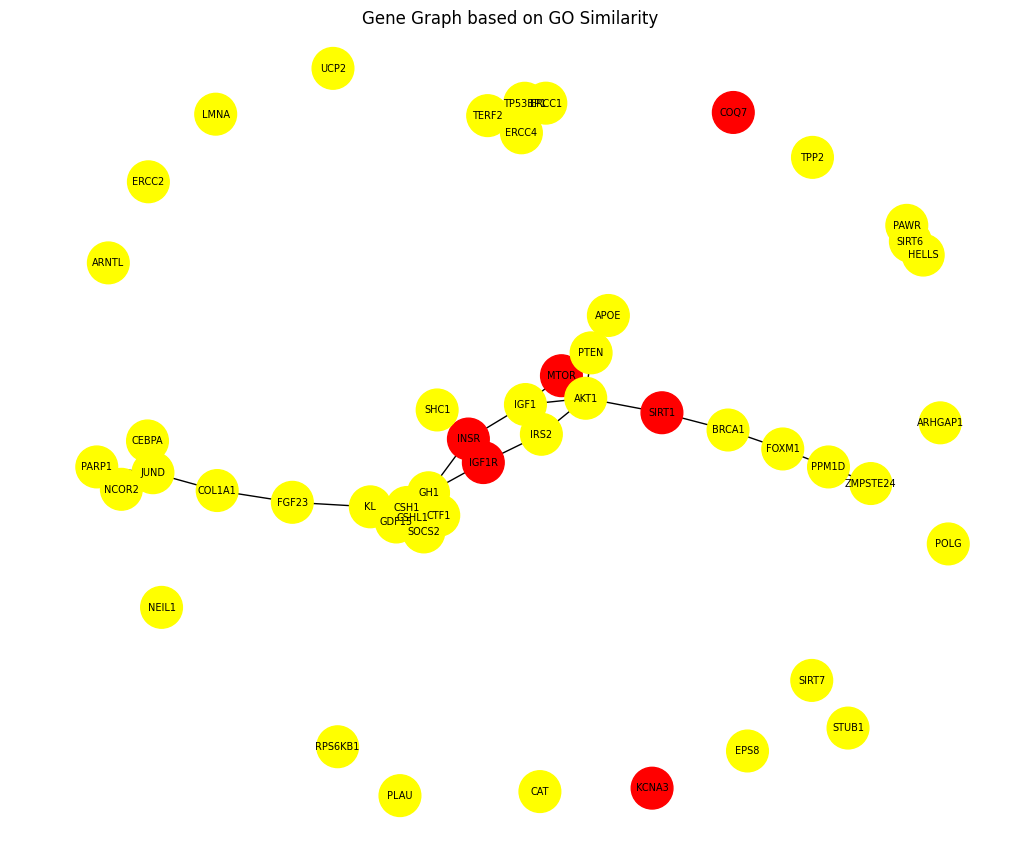

In [5]:
import matplotlib.pyplot as plt
sub_nodes = list(G.nodes())[:50]        # Take a small subset
subgraph = G.subgraph(sub_nodes)
node_colors = [
    "red" if subgraph.nodes[n]["label"] == 1 else "yellow"
    for n in subgraph.nodes()]

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(subgraph, seed=42)
nx.draw(
    subgraph,
    pos,
    node_color=node_colors,
    with_labels=True,
    node_size=900,
    font_size=7)
plt.title("Gene Graph based on GO Similarity")
plt.show()

In [6]:
ppi_df = pd.read_csv("9606.protein.links.v12.0.txt.gz",sep=" ") # Load PPI interactions
ppi_df.head()

info_df = pd.read_csv("9606.protein.info.v12.0.txt.gz",sep="\t") # Load protein info mapping

print("PPI shape:", ppi_df.shape)
print("Info shape:", info_df.shape)

PPI shape: (13715404, 3)
Info shape: (19699, 4)


In [7]:
#Filter High Confidence
ppi_df = ppi_df[ppi_df["combined_score"] > 700]  #700 = strong biological evidence
print("High confidence interactions:", len(ppi_df))

High confidence interactions: 472000


In [8]:
info_df.columns

protein_to_gene = dict(zip(info_df["#string_protein_id"],
        info_df["preferred_name"]))

In [9]:
ppi_df["gene1"] = ppi_df["protein1"].map(protein_to_gene)
ppi_df["gene2"] = ppi_df["protein2"].map(protein_to_gene)

ppi_df = ppi_df.dropna(subset=["gene1", "gene2"]) # Remove rows where mapping failed
print("After mapping:", ppi_df.shape)

After mapping: (472000, 5)


In [10]:
genes = df["Gene"].values
valid_genes = set(genes)

ppi_df = ppi_df[
    (ppi_df["gene1"].isin(valid_genes)) &
    (ppi_df["gene2"].isin(valid_genes))]

print("After filtering by GO genes:", ppi_df.shape)

After filtering by GO genes: (15558, 5)


In [11]:
for _, row in ppi_df.iterrows():
    G.add_edge(
        row["gene1"],
        row["gene2"],
        relation="PPI",
        weight=row["combined_score"]
    )

print("Total edges after adding PPI:", G.number_of_edges())

Total edges after adding PPI: 10903


In [12]:
#visualize only 30 nodes
import matplotlib.pyplot as plt
import networkx as nx

# nodes that have at least 1 edge
connected_nodes = [n for n in G.nodes() if G.degree(n) > 0]
# Select subset
sub_nodes = connected_nodes[:30]
subgraph = G.subgraph(sub_nodes)

In [13]:
ppi_edges = [] #PPI edges → Blue
similarity_edges = [] #GO similarity edges → Gray

for u, v, data in subgraph.edges(data=True):
    if "relation" in data and data["relation"] == "PPI":
        ppi_edges.append((u, v))
    else:
        similarity_edges.append((u, v))

In [14]:
node_colors = [
    "red" if subgraph.nodes[n]["label"] == 1 else "yellow"
    for n in subgraph.nodes()]

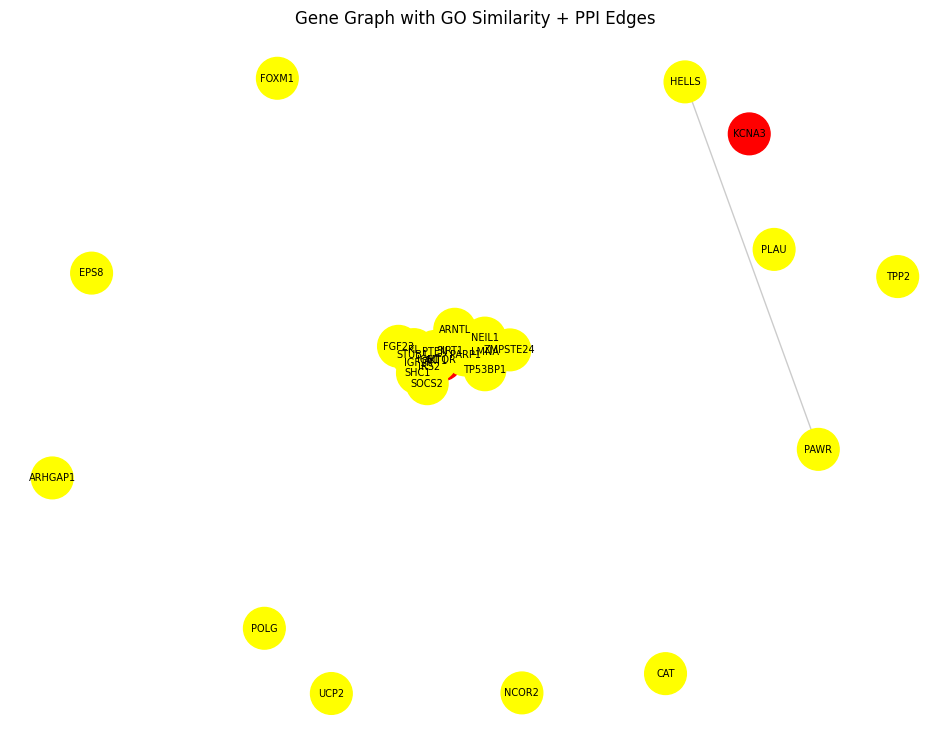

In [15]:
plt.figure(figsize=(12, 9))

pos = nx.spring_layout(subgraph,k=0.9, seed=42)

# Draw similarity edges
nx.draw_networkx_edges(
    subgraph,
    pos,
    edgelist=similarity_edges,
    edge_color="gray",
    alpha=0.4
)

# Draw PPI edges
nx.draw_networkx_edges(
    subgraph,
    pos,
    edgelist=ppi_edges,
    edge_color="blue",
    width=2
)

# Draw nodes
nx.draw_networkx_nodes(
    subgraph,
    pos,
    node_color=node_colors,
    node_size=900
)

# Draw labels
nx.draw_networkx_labels(
    subgraph,
    pos,
    font_size=7
)

plt.title("Gene Graph with GO Similarity + PPI Edges")
plt.axis("off")
plt.show()

#shows a dense central cluster (highly interacting genes)
# and many isolated nodes (no PPI edges within the chosen subset)

In [16]:
# Extract PPI edges only
ppi_edges = [
    (u, v) for u, v, d in G.edges(data=True)
    if d.get("relation") == "PPI"
]

In [17]:
# Create graph containing only PPI edges
ppi_graph = nx.Graph()
ppi_graph.add_edges_from(ppi_edges)

# Keep node attributes (labels)
for node in ppi_graph.nodes():
    if node in G.nodes():
        ppi_graph.nodes[node]["label"] = G.nodes[node]["label"]

In [18]:
connected_nodes = [n for n in ppi_graph.nodes() if ppi_graph.degree(n) > 0]

sub_nodes = connected_nodes[:40]   # visualize first 40 connected genes
subgraph = ppi_graph.subgraph(sub_nodes)

In [19]:
node_colors = [
    "red" if subgraph.nodes[n]["label"] == 1 else "yellow"
    for n in subgraph.nodes()
]

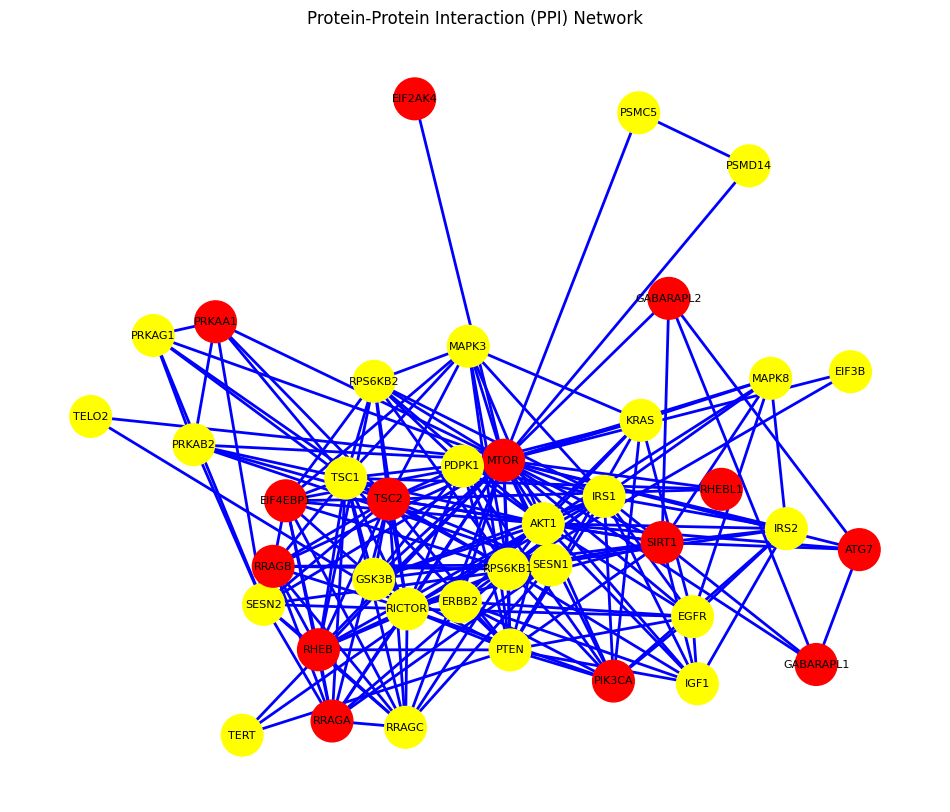

In [20]:
plt.figure(figsize=(12,10))

pos = nx.spring_layout(subgraph, k=1.1, seed=42)

nx.draw_networkx_edges(
    subgraph,
    pos,
    edge_color="blue",
    width=2
)

nx.draw_networkx_nodes(
    subgraph,
    pos,
    node_color=node_colors,
    node_size=900
)

nx.draw_networkx_labels(
    subgraph,
    pos,
    font_size=8
)

plt.title("Protein-Protein Interaction (PPI) Network")
plt.axis("off")
plt.show()

In [ ]:
import pandas as pd
import itertools

kegg_df = pd.read_csv(
    "kegg_pathway_gene.txt",
    sep="\t",
    header=None
)

kegg_df.columns = ["pathway", "gene"]

# remove KEGG prefixes
kegg_df["gene"] = kegg_df["gene"].str.replace("hsa:", "")
kegg_df["pathway"] = kegg_df["pathway"].str.replace("path:", "")

print(kegg_df.head())

    pathway   gene
0  hsa00010  10327
1  hsa00010    124
2  hsa00010    125
3  hsa00010    126
4  hsa00010    127


In [ ]:
pathway_edges = []

grouped = kegg_df.groupby("pathway")["gene"].apply(list)

for genes_in_pathway in grouped:

    # connect all gene pairs
    for g1, g2 in itertools.combinations(genes_in_pathway, 2):
        pathway_edges.append((g1, g2))

print("Total pathway edges:", len(pathway_edges))

Total pathway edges: 4527181


In [ ]:
pathway_edges_filtered = [
    (g1, g2)
    for g1, g2 in pathway_edges
    if g1 in valid_genes and g2 in valid_genes
]

print("Filtered pathway edges:", len(pathway_edges_filtered))

Filtered pathway edges: 0
